FIRST 5 ROWS
   Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0             3068          0.002400        0.1700                   16.12   
1             3042          0.000500        0.1542                   16.60   
2             2600          0.000300        0.1020                   18.70   
3             2800          0.000200        0.1600                   16.65   
4             1939          0.000138        0.1030                   20.06   

   Star type Star color Spectral Class  
0          0        Red              M  
1          0        Red              M  
2          0        Red              M  
3          0        Red              M  
4          0        Red              M  

Dataset Shape: (240, 7)

Columns:
['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 'Star type', 'Star color', 'Spectral Class']

Data Types:
Temperature (K)             int64
Luminosity(L/Lo)          float64
Radius(R/Ro)              flo

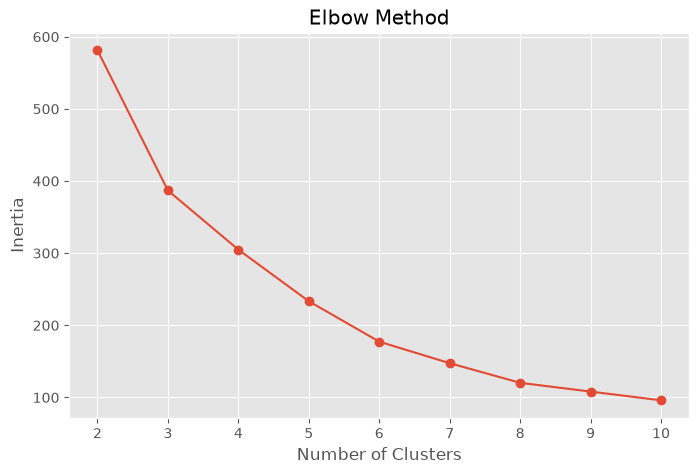


Silhouette Score: 0.466

Cluster Counts:
KMeans_Cluster
3    80
0    69
2    51
1    40
Name: count, dtype: int64


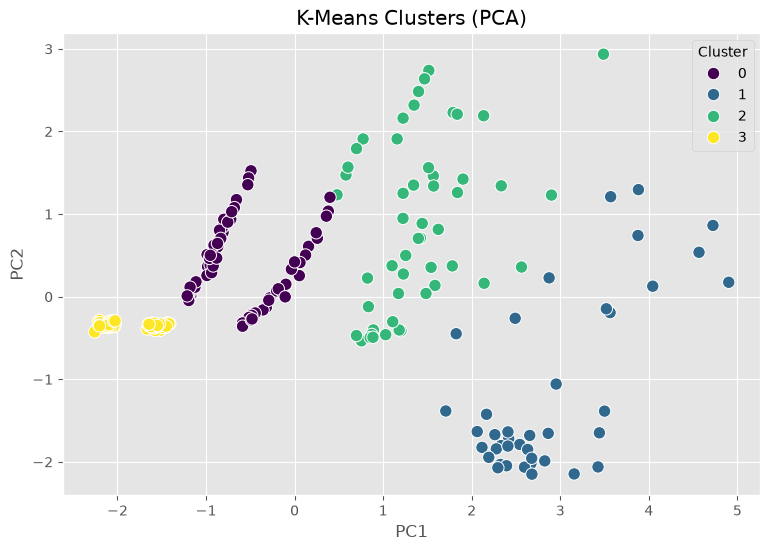


NLP ANALYSIS

Text Columns:
['Star color', 'Spectral Class']

TF-IDF Shape: (240, 8)

Text Cluster Counts:
Text_Cluster
0    112
2     56
1     51
3     21
Name: count, dtype: int64


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_901/3636091189.py:154: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include=["object"]).columns.tolist()


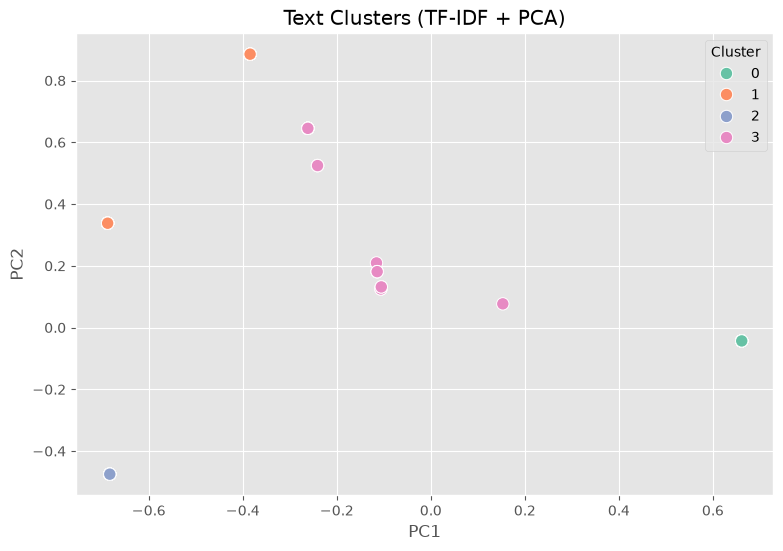


Top Words in Each Cluster

Cluster 0
red, yellowish, yellow, whitish, white, pale, orange, blue

Cluster 1
white, blue, yellowish, yellow, whitish, red, pale, orange

Cluster 2
blue, yellowish, yellow, whitish, white, red, pale, orange

Cluster 3
yellow, white, yellowish, orange, whitish, pale, red, blue

CLUSTER SUMMARY
                Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  \
KMeans_Cluster                                                    
0                  12414.492754        444.863019      1.461799   
1                  11405.700000     309246.525000   1366.897500   
2                  18731.215686     261267.647059     41.623078   
3                   3140.887500          0.003050      0.229080   

                Absolute magnitude(Mv)  Star type  
KMeans_Cluster                                     
0                             7.752797   2.420290  
1                            -9.654250   5.000000  
2                            -5.904647   3.784314  
3            

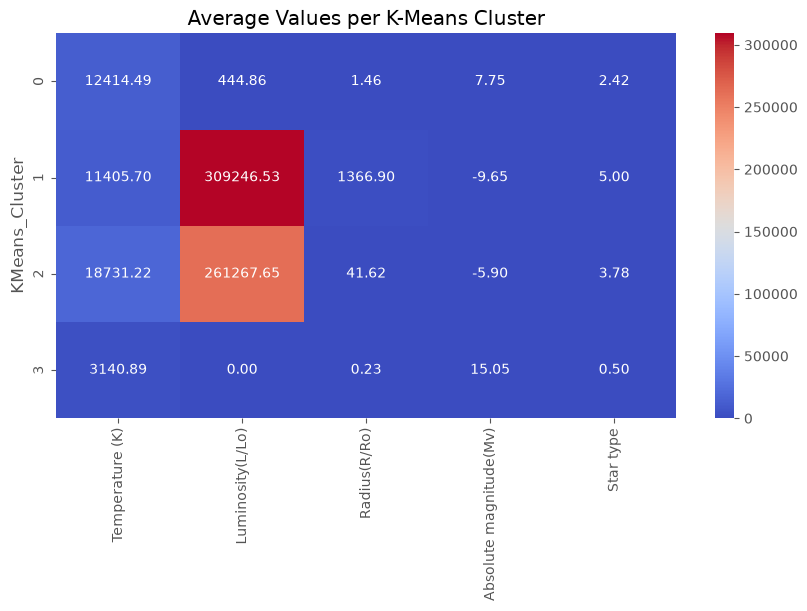


File saved successfully: stars_data_clustered.csv

Final Dataset Preview
   Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0             3068          0.002400        0.1700                   16.12   
1             3042          0.000500        0.1542                   16.60   
2             2600          0.000300        0.1020                   18.70   
3             2800          0.000200        0.1600                   16.65   
4             1939          0.000138        0.1030                   20.06   
5             2840          0.000650        0.1100                   16.98   
6             2637          0.000730        0.1270                   17.22   
7             2600          0.000400        0.0960                   17.40   
8             2650          0.000690        0.1100                   17.45   
9             2700          0.000180        0.1300                   16.05   

   Star type Star color Spectral Class  KMeans_Cluster combined_tex

In [1]:
# ==========================================================
# STARS DATA ANALYSIS USING K-MEANS + NLP (TF-IDF)
# ==========================================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")

# -----------------------------
# 2. Load Dataset
# -----------------------------
df = pd.read_csv("stars_data.csv")

print("="*60)
print("FIRST 5 ROWS")
print("="*60)
print(df.head())

print("\nDataset Shape:", df.shape)

# -----------------------------
# 3. Dataset Information
# -----------------------------
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# 4. Data Cleaning
# -----------------------------
data = df.copy()

# Remove duplicates
data.drop_duplicates(inplace=True)

# Remove empty rows
data.dropna(how="all", inplace=True)

print("\nCleaned Shape:", data.shape)

# ==========================================================
# PART A : K-MEANS USING NUMERICAL FEATURES
# ==========================================================

print("\n" + "="*60)
print("K-MEANS CLUSTERING")
print("="*60)

# Select numerical columns
num_cols = data.select_dtypes(include=["int64", "float64"]).columns

print("\nNumerical Columns:")
print(num_cols.tolist())

# Fill missing values
numeric_data = data[num_cols].fillna(data[num_cols].median())

# Scale data
scaler = StandardScaler()
X_numeric = scaler.fit_transform(numeric_data)

# -----------------------------
# Elbow Method
# -----------------------------
inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_numeric)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# -----------------------------
# Choose K
# -----------------------------
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

data["KMeans_Cluster"] = kmeans.fit_predict(X_numeric)

# Silhouette Score
score = silhouette_score(X_numeric, data["KMeans_Cluster"])

print("\nSilhouette Score:", round(score,3))

print("\nCluster Counts:")
print(data["KMeans_Cluster"].value_counts())

# -----------------------------
# PCA Visualization
# -----------------------------
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_numeric)

plt.figure(figsize=(9,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=data["KMeans_Cluster"],
    palette="viridis",
    s=80
)

plt.title("K-Means Clusters (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

# ==========================================================
# PART B : NLP USING TEXT DATA
# ==========================================================

print("\n" + "="*60)
print("NLP ANALYSIS")
print("="*60)

# Detect text columns
text_cols = data.select_dtypes(include=["object"]).columns.tolist()

print("\nText Columns:")
print(text_cols)

if len(text_cols) > 0:

    # Combine all text columns
    data["combined_text"] = (
        data[text_cols]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
    )

    # Text Cleaning
    def clean_text(text):
        text = text.lower()
        text = re.sub(r"[^a-zA-Z ]", " ", text)
        text = re.sub(r"\s+", " ", text)
        return text.strip()

    data["clean_text"] = data["combined_text"].apply(clean_text)

    # TF-IDF
    tfidf = TfidfVectorizer(
        stop_words="english",
        max_features=500
    )

    X_text = tfidf.fit_transform(data["clean_text"])

    print("\nTF-IDF Shape:", X_text.shape)

    # NLP K-Means
    text_model = KMeans(
        n_clusters=4,
        random_state=42,
        n_init=10
    )

    data["Text_Cluster"] = text_model.fit_predict(X_text)

    print("\nText Cluster Counts:")
    print(data["Text_Cluster"].value_counts())

    # PCA for Text
    text_pca = PCA(n_components=2)
    X_text_pca = text_pca.fit_transform(X_text.toarray())

    plt.figure(figsize=(9,6))

    sns.scatterplot(
        x=X_text_pca[:,0],
        y=X_text_pca[:,1],
        hue=data["Text_Cluster"],
        palette="Set2",
        s=80
    )

    plt.title("Text Clusters (TF-IDF + PCA)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster")
    plt.show()

    # Top Words
    terms = tfidf.get_feature_names_out()
    order = text_model.cluster_centers_.argsort()[:, ::-1]

    print("\nTop Words in Each Cluster")

    for i in range(4):
        print("\nCluster", i)
        words = [terms[ind] for ind in order[i,:10]]
        print(", ".join(words))

else:
    print("\nNo text columns found. NLP section skipped.")

# ==========================================================
# PART C : SUMMARY
# ==========================================================

print("\n" + "="*60)
print("CLUSTER SUMMARY")
print("="*60)

summary = data.groupby("KMeans_Cluster")[num_cols].mean()

print(summary)

# Heatmap
plt.figure(figsize=(10,5))

sns.heatmap(
    summary,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Average Values per K-Means Cluster")
plt.show()

# ==========================================================
# Save Results
# ==========================================================

data.to_csv("stars_data_clustered.csv", index=False)

print("\nFile saved successfully: stars_data_clustered.csv")

# Display final data
print("\nFinal Dataset Preview")
print(data.head(10))